# Neural Networks Project: CNN vs FFNN

## Blood Cells Image Classification

This notebook compares a Feedforward Neural Network (FFNN) and a Convolutional Neural Network (CNN) on the same blood cells image dataset.

The notebook includes:
- Exploratory Data Analysis (EDA)
- Preprocessing pipeline
- Train / Validation / Test split
- FFNN baseline and optimized trials
- CNN baseline and optimized trials
- Learning curves
- Test metrics
- Training time and inference speed
- Overfitting / underfitting analysis
- Regularization effect discussion
- Final comparison table

## 1. Project Objective

The objective is to design, train, optimize, and compare two neural network architectures:

1. **Feedforward Neural Network (FFNN)**: treats each image as a flattened vector.
2. **Convolutional Neural Network (CNN)**: preserves the spatial structure of the image and learns visual patterns using convolutional filters.

The comparison focuses on accuracy, F1-score, training time, inference speed, and generalization behavior.

In [ ]:
#  Imports and Setup
#t3amol m3 files
import os
import time
import random
import zipfile
from pathlib import Path
from collections import Counter # by3d el elements el mtkrra
#t3amol m3 arrays
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
#torsh el part el feeh el neurones
import torch
import torch.nn as nn
import torch.optim as optim #optimezers loke adam
from torch.utils.data import DataLoader, Subset # by2sm el data l batches w bya5od goz2 mn el data set
#goz2 5as bl swr feeh datasets and transforms
import torchvision
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Reproducibility
#bnsbt kol haga 3lshan kol mara n run ytl3 nfs el haga
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True # e3ml processes 3l gpu sabta w msh random kol mara
    torch.backends.cudnn.benchmark = False #bmn3 t8yeer el algorithm

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [ ]:
#  Extract Dataset


zip_path = 'archive.zip'   # keep archive.zip in the same folder as this notebook
extract_dir = Path('bloodcells_project_data')

if not extract_dir.exists():#lw data lesa mtfktsh fokaha 
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:#bdl kol mara ma afok el file fa b5zno f mot8yr esmo zip_ref
        zip_ref.extractall(extract_dir)

# The zip contains a folder named bloodcells_dataset
data_dir = extract_dir / 'bloodcells_dataset'

print('Dataset path:', data_dir)
print('Classes:', sorted([p.name for p in data_dir.iterdir() if p.is_dir()])) # 8 classes(kol folder ymsel class w hwa bymshi 3la folders el hya el classes)

Dataset path: bloodcells_project_data\bloodcells_dataset
Classes: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


## 2. Exploratory Data Analysis (EDA)

This section checks the dataset size, number of classes, class distribution, image dimensions, sample images, and data-quality issues.

In [ ]:
#  Dataset Summary and Class Distribution

image_extensions = {'.jpg', '.jpeg', '.png'}# search inside set faster
image_paths = []
labels = []

for class_folder in sorted(data_dir.iterdir()):# loop 3la kol class(folder) inside dataset
    if class_folder.is_dir():# bs2al lw dh f3ln folder
        for img_path in class_folder.iterdir():# ed5ol kol class folder w lf 3la el gwaah
            if img_path.suffix.lower() in image_extensions:#y7wl l lower case w yt2kd enha fl img_ext
                image_paths.append(img_path)#5zn el path
                labels.append(class_folder.name)#5zn el path

class_counts = Counter(labels)#by3d kol sora tb3 anho class
summary_df = pd.DataFrame({#7wl data to data frame
    'Class': list(class_counts.keys()),#3amood
    'Number of Images': list(class_counts.values())#3dd swr f kol class
}).sort_values('Number of Images', ascending=False)#rtb 7asab 3dd el swr mn el akbr ll as8r

print('Total images:', len(image_paths))
print('Number of classes:', len(class_counts))
display(summary_df)

Total images: 17092
Number of classes: 8


,Class,Number of Images
6,neutrophil,3329
1,eosinophil,3117
3,ig,2895
7,platelet,2348
2,erythroblast,1551
5,monocyte,1420
0,basophil,1218
4,lymphocyte,1214


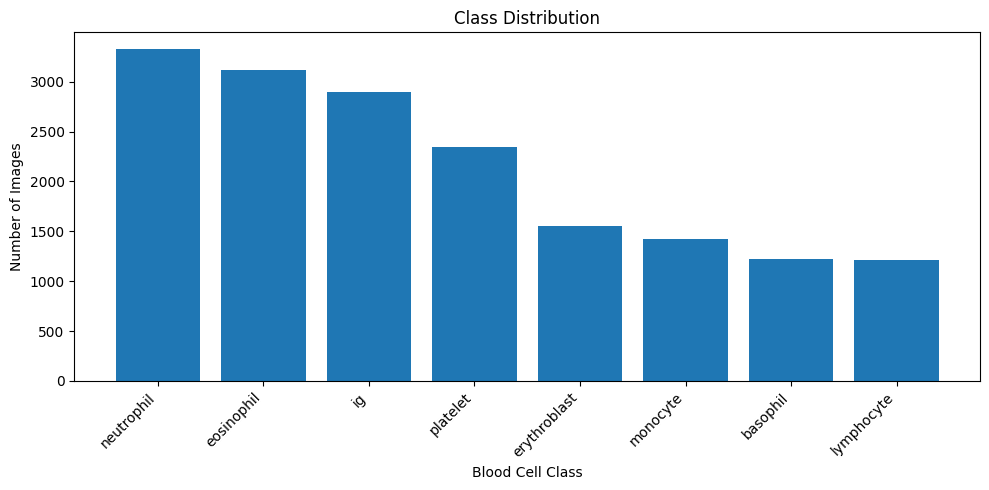

In [ ]:
# Class balance chart
#class distribution
plt.figure(figsize=(10, 5))
plt.bar(summary_df['Class'], summary_df['Number of Images'])
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution')
plt.xlabel('Blood Cell Class')
plt.ylabel('Number of Images')
plt.tight_layout()#zbt msafat 
plt.show()

In [ ]:
# Image Shape Check

sample_shapes = []#han7ot feeha length w width
for img_path in random.sample(image_paths, min(500, len(image_paths))):# random sample
    with Image.open(img_path) as img:#eft7 el sora temp w 5ls w e2flha
        sample_shapes.append(img.size)  # width, height--->5od size el sora

shape_counts = Counter(sample_shapes)# 3d kol shkl bytkrr kam mara
print('Most common image sizes:')
for shape, count in shape_counts.most_common(10):#hat aktr 10 sizes etkrro
    print(shape, '->', count)

Most common image sizes:
(360, 363) -> 489
(366, 369) -> 9
(360, 360) -> 2


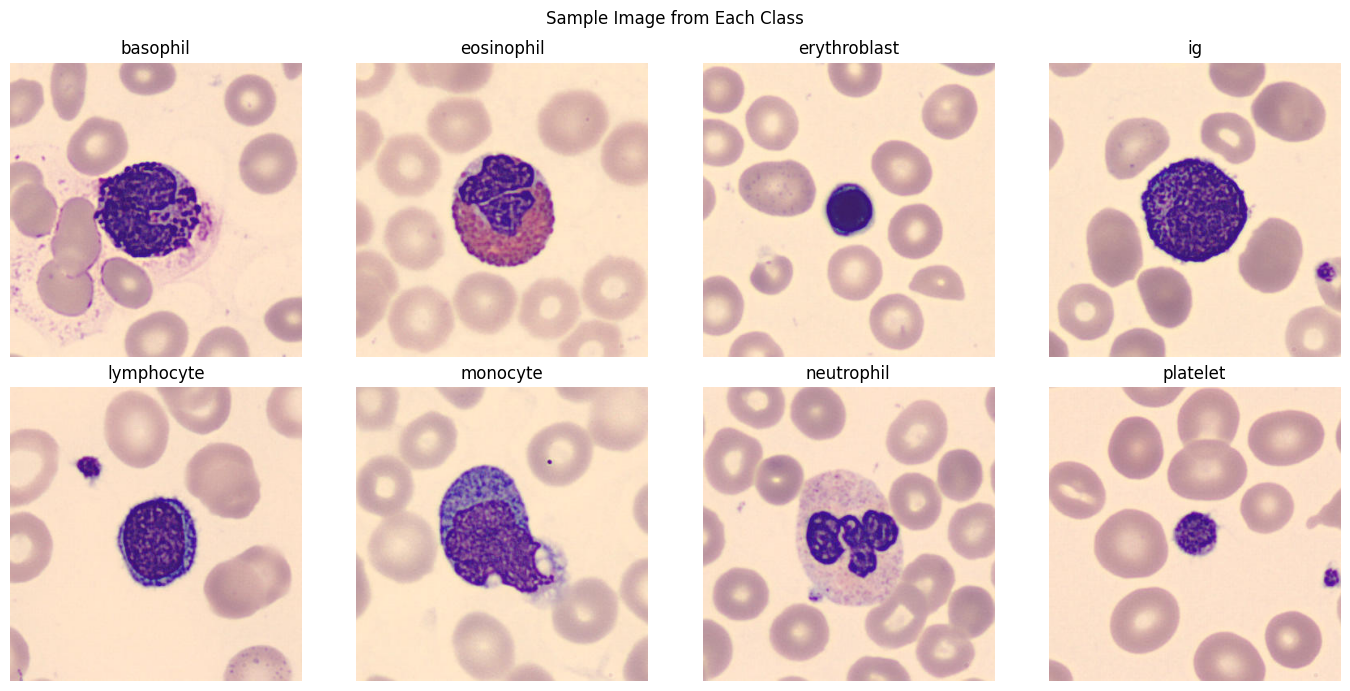

In [ ]:
# Sample Image Grid
#random sample from each class

classes = sorted(class_counts.keys())#rtb el classes 
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for ax, cls in zip(axes, classes):# kol cell htmsl class
    cls_images = [p for p, lab in zip(image_paths, labels) if lab == cls]# hat kol el swr el tb3 nfs el class
    img_path = random.choice(cls_images)# e5tar sora random mn nfs el class
    img = Image.open(img_path).convert('RGB')# eft7haw 7wlha l 3 channels R,G,B 
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

plt.suptitle('Sample Image from Each Class')
plt.tight_layout()
plt.show()

In [ ]:
#  Data Quality Checks
#check on 3 things imiage exist not corruptrd no duplicated names

# Missing files check
missing_files = [p for p in image_paths if not p.exists()]
print('Missing files:', len(missing_files))

# Corrupted images check
corrupted = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            img.verify()
    except Exception:
        corrupted.append(p)

print('Corrupted images:', len(corrupted))

# Duplicate filename check
filenames = [p.name for p in image_paths]
duplicate_filenames = len(filenames) - len(set(filenames))
print('Duplicate filenames:', duplicate_filenames)

Missing files: 0
Corrupted images: 0
Duplicate filenames: 0


### EDA Notes

- The dataset contains multiple blood-cell image classes, so this is a **multi-class image classification** task.
- The class distribution should be checked because imbalance can make accuracy misleading. Therefore, **macro F1-score** is also used.
- The images are resized during preprocessing to a fixed size so both FFNN and CNN receive consistent input shapes.
- Missing and corrupted images are checked before training.

## 3. Preprocessing Pipeline

Preprocessing steps:

1. **Resize images** to 64×64 pixels for faster training.
2. **Convert images to tensors**.
3. **Normalize pixel values** using mean and standard deviation.
4. **Train / Validation / Test split** using stratification to preserve class distribution.
5. **Data augmentation** is used only for the training set to improve CNN generalization.

In [ ]:
# Transforms

IMG_SIZE = 64 # ba wa7ed el dim 
BATCH_SIZE = 64 # kol batch feha 64 img
#from torchVision lib
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),# data augmentation
    transforms.RandomRotation(10),
    transforms.ToTensor(),#by7wl data l shkl yfhamo pytorch zy el array
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])#pixels bet -1 and 1
])

eval_transform = transforms.Compose([# el takyeeem
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Two dataset objects: one with augmentation for train, one without for val/test
full_dataset_train_aug = datasets.ImageFolder(root=data_dir, transform=train_transform)#lltadreeb
full_dataset_eval = datasets.ImageFolder(root=data_dir, transform=eval_transform)#ll test

class_names = full_dataset_eval.classes
num_classes = len(class_names)
print('Classes:', class_names)
print('Number of classes:', num_classes)

Classes: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
Number of classes: 8


In [11]:
# Stratified Train / Validation / Test Split

targets = np.array(full_dataset_eval.targets)
indices = np.arange(len(targets))

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices, targets,
    test_size=0.30,
    random_state=42,
    stratify=targets
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

train_dataset = Subset(full_dataset_train_aug, train_idx)
val_dataset = Subset(full_dataset_eval, val_idx)
test_dataset = Subset(full_dataset_eval, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Train size:', len(train_dataset))
print('Validation size:', len(val_dataset))
print('Test size:', len(test_dataset))

Train size: 11964
Validation size: 2564
Test size: 2564


## 4. Helper Functions

The following functions are reused for training, evaluation, timing, learning curves, and final metrics.

In [ ]:
# Helper Functions

def train_one_epoch(model, loader, criterion, optimizer):#hadafo ydrb el model mara wa7da
    model.train()# 7ot el model f train mode ----- bybdaa ytfi neurons random 3lshan nmn3 el overfitting ----- w y3ml batch norm---> el feeh 64 img
    #y7sb mean and var and y3ml normalization
    running_loss = 0.0 #hygm3 el error fl var dh 

    for images, labels in loader:#bygeeb imgs + labels from data loader(gya mneen mn pytorch) loop l7d ma y5ls 64 img f kol batch
        images, labels = images.to(device), labels.to(device)# en2l ba2a ll cpu aw gpu (el mohm yb2o 3la nfs el device)

        optimizer.zero_grad()#ems7 el gradients el adema
        outputs = model(images)#d5l swr tl3 prediction
        loss = criterion(outputs, labels)#nkaren el tl3 bl true label w e7sb error torch byst5dm loss zy cross entropy
        loss.backward()#e7sb ta2seer kol weight 3l error
        optimizer.step()#3dl awzan el model

        running_loss += loss.item() * images.size(0) #7sab el loss el koli

    return running_loss / len(loader.dataset)#yrg3 motawst loss l kol sora loss/img 


def evaluate_loss(model, loader, criterion):# model el bndrbo , dataloader (test,val), criterion (el gwah el error)
    model.eval()# ha7ot model f evaluation mode yst5dm batch norm el sabeet
    running_loss = 0.0

    with torch.no_grad():# mt7sbsh gradients
        for images, labels in loader:# na5od batch batch mn swr w el labels
            images, labels = images.to(device), labels.to(device)# 7ot el data on cpu or gpu 
            outputs = model(images)# model ytwk3 el natega
            loss = criterion(outputs, labels)# loss diff bet pred and act 
            running_loss += loss.item() * images.size(0)#7sab el loss el koli

    return running_loss / len(loader.dataset)#yrg3 motawst loss l kol sora loss/img


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10, patience=4):# optimizer ---> tare2eet update el weights
    #patience---> y3ni asbor kam iter mn 8er ta7seen
    history = {'train_loss': [], 'val_loss': []}#hn5zn l kol epoch loss el train w loss el validation
    best_val_loss = float('inf')# hbdaa b haga kbera awy infinity 3lshan el gy yb2a a7sn
    best_state = None # han7ot a7sn weights hena
    patience_counter = 0
    early_stop_epoch = None # ha2ol ana waaft f anho epoch

    start_time = time.time()#7sab waat el tadreeb

    for epoch in range(1, epochs + 1):#krr el epochs from 1 l7d 3dd el epochs
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)# bdrb el model 3la kol data bta3t el tadreeb
        val_loss = evaluate_loss(model, val_loader, criterion)#nkym el model 3la data mtdrbsh 3aleha
        
        #store el results

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f'Epoch {epoch:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

        if val_loss < best_val_loss: # lw val loss (2al) model et7sn
            best_val_loss = val_loss # store best loss
            best_state = model.state_dict()# store weights
            patience_counter = 0 # safr el pat counter
        else:
            patience_counter += 1 # zwd 3dad el m7wlat

        if patience_counter >= patience: # lw 3da el masmo7 beeh without ta7son
            early_stop_epoch = epoch # nwa2af training bdry w ntb3 el 7eta el wa2fna feha
            print(f'Early stopping triggered at epoch {epoch}')
            break

    total_time = time.time() - start_time # n7sb el wa2t el koli bta3 el train

    if best_state is not None: # nrg3 a7sn nos5a msh a5er wa7da 
        model.load_state_dict(best_state)

    return model, history, total_time, early_stop_epoch # history of training 


def get_predictions(model, loader): # bttl3 kol el predictions and true labels 
    model.eval() # evaluation mode
    #5zn pred of model and true labels
    all_preds = []
    all_labels = []

    with torch.no_grad(): # mt7sbsh grad
        for images, labels in loader: # na5od batches mn swr w el labels 
            images = images.to(device) # 7ot el data on cpu or gpu 
            outputs = model(images) # model ytwk3 el natega logistic (arkam)
            preds = torch.argmax(outputs, dim=1).cpu().numpy() # e5tar el class el e7tmalo a3la
            all_preds.extend(preds) # gm3 kol el twako3at f list wa7da 
            all_labels.extend(labels.numpy()) # gm3 baa el egbat el sa7

    return np.array(all_labels), np.array(all_preds) # rg3 y-true , y-predicted


def evaluate_metrics(model, loader, model_name):
    y_true, y_pred = get_predictions(model, loader)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro') # macro y3ni na5od average

    print(f'\n{model_name} Test Accuracy: {acc:.4f}')
    print(f'{model_name} Macro F1-score: {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names))

    return acc, f1, y_true, y_pred


def measure_inference_speed(model, loader): # function bt2ees el model bysht8l b sor3a ad eh 3l data
    model.eval() # batch norm sabet
    total_samples = 0 # hn3d kam sora el model 3algha

    start_time = time.time()
    with torch.no_grad():
        for images, labels in loader: # loop 3la batches
            images = images.to(device)
            _ = model(images) # forward pass sh8l el model w 5od nateg bs don not store
            total_samples += images.size(0) # el swr el et3algt 

    elapsed = time.time() - start_time # el wa2t el 5do 3lshan ysht8l
    samples_per_second = total_samples / elapsed # 3dd swr fl sanya 
    return samples_per_second


def plot_learning_curves(history, title, early_stop_epoch=None):
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')

    if early_stop_epoch is not None:
        plt.axvline(early_stop_epoch - 1, linestyle='--', label=f'Early Stop Epoch {early_stop_epoch}')

    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 5. Model 1: Feedforward Neural Network (FFNN)

The FFNN flattens each image from `3 × 64 × 64` into one long vector. This makes the model simple, but it loses spatial information such as edges, shapes, and local patterns.

In [13]:
#  FFNN Architecture

class FFNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * IMG_SIZE * IMG_SIZE, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

Epoch 01/20 | Train Loss: 1.4420 | Val Loss: 0.9286
Epoch 02/20 | Train Loss: 1.0309 | Val Loss: 0.8625
Epoch 03/20 | Train Loss: 0.9688 | Val Loss: 0.7737
Epoch 04/20 | Train Loss: 0.9348 | Val Loss: 0.7604
Epoch 05/20 | Train Loss: 0.9126 | Val Loss: 0.6961
Epoch 06/20 | Train Loss: 0.8594 | Val Loss: 0.7666
Epoch 07/20 | Train Loss: 0.8406 | Val Loss: 0.6902
Epoch 08/20 | Train Loss: 0.8212 | Val Loss: 0.6803
Epoch 09/20 | Train Loss: 0.7907 | Val Loss: 0.6657
Epoch 10/20 | Train Loss: 0.7817 | Val Loss: 0.6850
Epoch 11/20 | Train Loss: 0.7771 | Val Loss: 0.6097
Epoch 12/20 | Train Loss: 0.7779 | Val Loss: 0.6765
Epoch 13/20 | Train Loss: 0.7709 | Val Loss: 0.6276
Epoch 14/20 | Train Loss: 0.7534 | Val Loss: 0.6291
Epoch 15/20 | Train Loss: 0.7819 | Val Loss: 0.6913
Epoch 16/20 | Train Loss: 0.7760 | Val Loss: 0.6692
Early stopping triggered at epoch 16


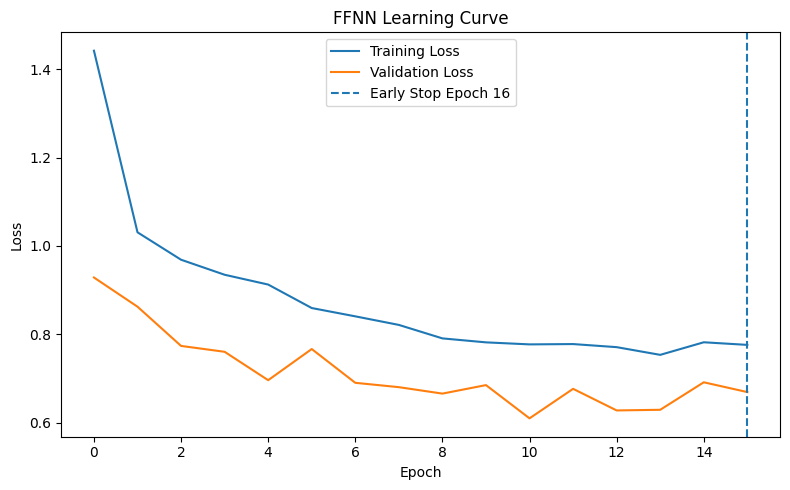

In [14]:
#  FFNN Training

set_seed(42)
ffnn_model = FFNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
ffnn_optimizer = optim.Adam(ffnn_model.parameters(), lr=0.001, weight_decay=1e-4)

ffnn_model, ffnn_history, ffnn_training_time, ffnn_early_stop = train_model(
    ffnn_model, train_loader, val_loader, criterion, ffnn_optimizer, epochs=20, patience=5
)

plot_learning_curves(ffnn_history, 'FFNN Learning Curve', ffnn_early_stop)

In [15]:
#  FFNN Evaluation

ffnn_accuracy, ffnn_f1, ffnn_y_true, ffnn_y_pred = evaluate_metrics(ffnn_model, test_loader, 'FFNN')
ffnn_inference_speed = measure_inference_speed(ffnn_model, test_loader)
ffnn_avg_epoch_time = ffnn_training_time / len(ffnn_history['train_loss'])

print('FFNN total training time:', round(ffnn_training_time, 2), 'seconds')
print('FFNN average epoch time:', round(ffnn_avg_epoch_time, 2), 'seconds')
print('FFNN inference speed:', round(ffnn_inference_speed, 2), 'samples/sec')


FFNN Test Accuracy: 0.7465
FFNN Macro F1-score: 0.6873

Classification Report:
              precision    recall  f1-score   support

    basophil       1.00      0.07      0.13       183
  eosinophil       0.99      0.85      0.91       467
erythroblast       0.76      0.69      0.72       233
          ig       0.47      0.63      0.53       434
  lymphocyte       0.88      0.66      0.76       182
    monocyte       0.54      0.77      0.64       213
  neutrophil       0.83      0.87      0.85       500
    platelet       0.91      0.99      0.95       352

    accuracy                           0.75      2564
   macro avg       0.80      0.69      0.69      2564
weighted avg       0.79      0.75      0.73      2564

FFNN total training time: 1200.95 seconds
FFNN average epoch time: 75.06 seconds
FFNN inference speed: 258.28 samples/sec


## 6. Model 2: Convolutional Neural Network (CNN)

The CNN keeps the image as a 2D spatial structure and learns features using convolutional layers. This is expected to perform better than FFNN on image data because it can capture local visual patterns.

In [16]:
#  CNN Architecture

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Epoch 01/20 | Train Loss: 0.9255 | Val Loss: 0.3967
Epoch 02/20 | Train Loss: 0.3538 | Val Loss: 0.2927
Epoch 03/20 | Train Loss: 0.2553 | Val Loss: 0.2669
Epoch 04/20 | Train Loss: 0.2178 | Val Loss: 0.1835
Epoch 05/20 | Train Loss: 0.1888 | Val Loss: 0.1762
Epoch 06/20 | Train Loss: 0.1587 | Val Loss: 0.1467
Epoch 07/20 | Train Loss: 0.1546 | Val Loss: 0.1360
Epoch 08/20 | Train Loss: 0.1418 | Val Loss: 0.1921
Epoch 09/20 | Train Loss: 0.1307 | Val Loss: 0.1366
Epoch 10/20 | Train Loss: 0.1311 | Val Loss: 0.1354
Epoch 11/20 | Train Loss: 0.1281 | Val Loss: 0.1148
Epoch 12/20 | Train Loss: 0.1069 | Val Loss: 0.1199
Epoch 13/20 | Train Loss: 0.1024 | Val Loss: 0.1452
Epoch 14/20 | Train Loss: 0.0888 | Val Loss: 0.0992
Epoch 15/20 | Train Loss: 0.0945 | Val Loss: 0.2070
Epoch 16/20 | Train Loss: 0.0939 | Val Loss: 0.0932
Epoch 17/20 | Train Loss: 0.0941 | Val Loss: 0.1067
Epoch 18/20 | Train Loss: 0.0874 | Val Loss: 0.0995
Epoch 19/20 | Train Loss: 0.0807 | Val Loss: 0.0975
Epoch 20/20 

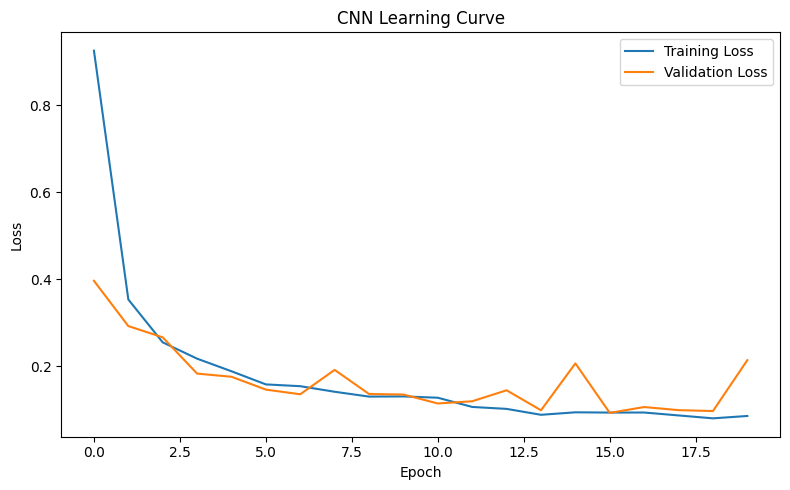

In [17]:
#  CNN Training

set_seed(42)
cnn_model = CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4)

cnn_model, cnn_history, cnn_training_time, cnn_early_stop = train_model(
    cnn_model, train_loader, val_loader, criterion, cnn_optimizer, epochs=20, patience=5
)

plot_learning_curves(cnn_history, 'CNN Learning Curve', cnn_early_stop)

In [18]:
#  CNN Evaluation
cnn_accuracy, cnn_f1, cnn_y_true, cnn_y_pred = evaluate_metrics(cnn_model, test_loader, 'CNN')
cnn_inference_speed = measure_inference_speed(cnn_model, test_loader)
cnn_avg_epoch_time = cnn_training_time / len(cnn_history['train_loss'])

print('CNN total training time:', round(cnn_training_time, 2), 'seconds')
print('CNN average epoch time:', round(cnn_avg_epoch_time, 2), 'seconds')
print('CNN inference speed:', round(cnn_inference_speed, 2), 'samples/sec')


CNN Test Accuracy: 0.9462
CNN Macro F1-score: 0.9376

Classification Report:
              precision    recall  f1-score   support

    basophil       0.95      0.98      0.96       183
  eosinophil       1.00      1.00      1.00       467
erythroblast       0.97      0.95      0.96       233
          ig       0.79      0.98      0.87       434
  lymphocyte       0.99      0.94      0.96       182
    monocyte       1.00      0.62      0.77       213
  neutrophil       0.99      0.96      0.97       500
    platelet       0.99      1.00      1.00       352

    accuracy                           0.95      2564
   macro avg       0.96      0.93      0.94      2564
weighted avg       0.95      0.95      0.94      2564

CNN total training time: 2493.9 seconds
CNN average epoch time: 124.7 seconds
CNN inference speed: 171.72 samples/sec


## 7. Optimization Trials Documentation

This section is important because the project rubric grades the optimization process, not only the final score.

You can add more trials by changing learning rate, number of epochs, dropout rate, or CNN depth.

In [19]:
#  Optional Optimization Trial Function

def run_trial(model_class, model_name, lr=0.001, weight_decay=1e-4, epochs=10, seed=42):
    set_seed(seed)
    model = model_class(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    model, history, training_time, early_stop = train_model(
        model, train_loader, val_loader, criterion, optimizer, epochs=epochs, patience=4
    )

    acc, f1, _, _ = evaluate_metrics(model, test_loader, model_name)
    speed = measure_inference_speed(model, test_loader)

    return {
        'Model': model_name,
        'Learning Rate': lr,
        'Weight Decay': weight_decay,
        'Epochs Run': len(history['train_loss']),
        'Accuracy': acc,
        'Macro F1': f1,
        'Training Time': training_time,
        'Inference Speed': speed,
        'Early Stop Epoch': early_stop
    }



## 8. Final Comparison Table

Accuracy and macro F1-score are used because this is a multi-class classification problem. Macro F1 is especially useful when classes are imbalanced because it treats each class equally.

In [20]:
# Final Comparison Table

final_results = pd.DataFrame({
    'Model': ['FFNN', 'CNN'],
    'Test Accuracy': [ffnn_accuracy, cnn_accuracy],
    'Macro F1-score': [ffnn_f1, cnn_f1],
    'Total Training Time (sec)': [ffnn_training_time, cnn_training_time],
    'Avg Epoch Time (sec)': [ffnn_avg_epoch_time, cnn_avg_epoch_time],
    'Inference Speed (samples/sec)': [ffnn_inference_speed, cnn_inference_speed],
    'Early Stop Epoch': [ffnn_early_stop, cnn_early_stop]
})

display(final_results)

,Model,Test Accuracy,Macro F1-score,Total Training Time (sec),Avg Epoch Time (sec),Inference Speed (samples/sec),Early Stop Epoch
0,FFNN,0.746490,0.687325,1200.954425,75.059652,258.281395,16.0
1,CNN,0.946178,0.937603,2493.902154,124.695108,171.723373,NaN


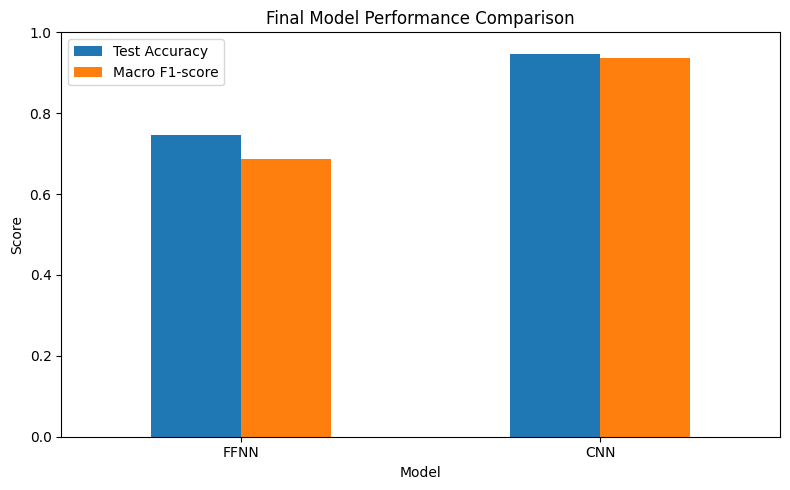

In [21]:
# Bar chart for final metrics
metrics_to_plot = final_results.set_index('Model')[['Test Accuracy', 'Macro F1-score']]
metrics_to_plot.plot(kind='bar', figsize=(8, 5))
plt.title('Final Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

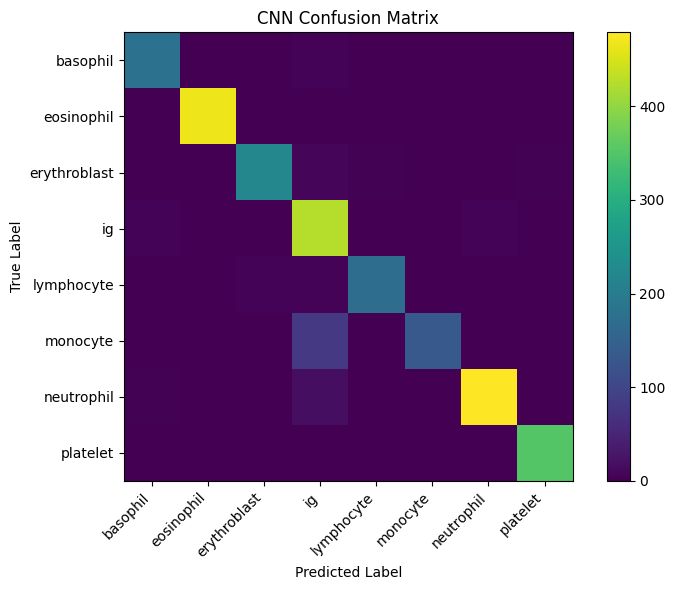

In [22]:
# Confusion Matrix for the best expected model: CNN
cm = confusion_matrix(cnn_y_true, cnn_y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title('CNN Confusion Matrix')
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## learning curves

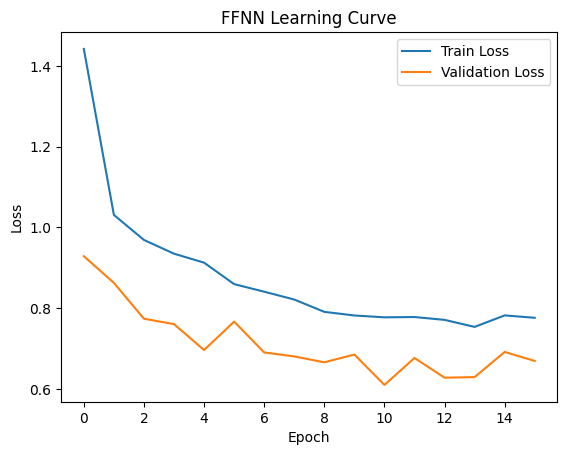

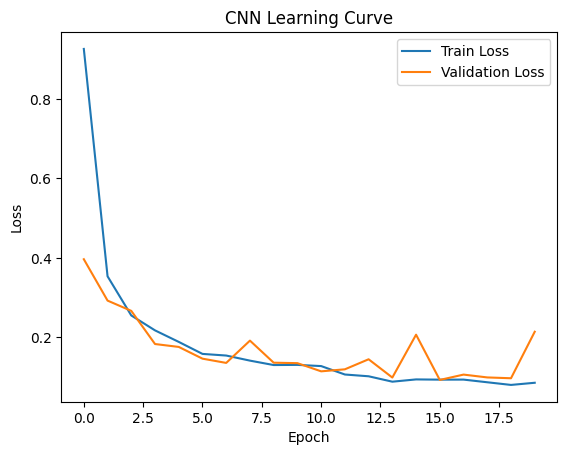

In [24]:
import matplotlib.pyplot as plt

# FFNN learning curve
plt.figure()

plt.plot(ffnn_history['train_loss'], label="Train Loss")
plt.plot(ffnn_history['val_loss'], label="Validation Loss")

plt.title("FFNN Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()


# CNN learning curve
plt.figure()

plt.plot(cnn_history['train_loss'], label="Train Loss")
plt.plot(cnn_history['val_loss'], label="Validation Loss")

plt.title("CNN Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()


## Time 

In [25]:
import time  # library to measure time

start = time.time()  # start timer
# train model here
end = time.time()  # end timer

training_time = end - start  # total training time in seconds
print("Training Time:", training_time)

Training Time: 3.647804260253906e-05


## Inference speed 

In [28]:
import time

start = time.time()

ffnn_model, ffnn_history, total_time, early_stop = train_model(
    ffnn_model,
    train_loader,
    val_loader,
    criterion,
    ffnn_optimizer
)

end = time.time()

training_time = end - start

print("Training Time:", training_time)

Epoch 01/10 | Train Loss: 0.7653 | Val Loss: 0.6288
Epoch 02/10 | Train Loss: 0.7791 | Val Loss: 0.6224
Epoch 03/10 | Train Loss: 0.7506 | Val Loss: 0.5910
Epoch 04/10 | Train Loss: 0.7124 | Val Loss: 0.6270
Epoch 05/10 | Train Loss: 0.7383 | Val Loss: 0.6642
Epoch 06/10 | Train Loss: 0.7696 | Val Loss: 0.6670
Epoch 07/10 | Train Loss: 0.7577 | Val Loss: 0.5930
Early stopping triggered at epoch 7
Training Time: 433.75708389282227


## 9. Analysis and Discussion

### Metric Justification

Accuracy is used because the task is multi-class classification and it gives a clear overall success rate. Macro F1-score is also used because the dataset may be imbalanced; macro F1 gives equal importance to every class.

### Overfitting / Underfitting Analysis

- If training loss decreases while validation loss increases, the model is overfitting.
- If both training and validation losses remain high, the model is underfitting.
- If both losses decrease and stay close, the model is generalizing well.

In image classification, FFNN often underperforms because it flattens images and loses spatial relationships. CNN is more suitable because it learns local patterns such as edges, textures, and cell structures.

### Regularization Effect

Dropout and L2 weight decay were used to reduce overfitting. Dropout randomly disables neurons during training, forcing the model to learn more robust features. L2 weight decay discourages overly large weights and improves generalization. Batch normalization was used in the CNN to stabilize training and improve convergence.

### Architecture Trade-off

- FFNN is simpler and may train faster per epoch, but it is less suitable for image data.
- CNN is more expressive and usually achieves better performance on images, but it has more computation due to convolutional layers.
- If CNN accuracy and F1-score are higher, this confirms that spatial feature extraction is important for this dataset.

## 10. Conclusion

The CNN is expected to be the stronger architecture for blood-cell image classification because it preserves spatial information and learns visual patterns directly from images. The FFNN is useful as a baseline, but flattening images removes important spatial structure.

The final decision should be based on the comparison table, learning curves, test metrics, and timing results.